# Análisis Exploratorio de Datos (EDA)
## Clasificador de Noticias: Actualidad vs Interés General

Este notebook realiza el análisis exploratorio de los datasets MIND y Google News.

**Objetivos:**
1. Cargar y explorar ambos datasets
2. Analizar distribución de categorías
3. Estadísticas de texto
4. Detección de duplicados
5. Visualizaciones

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerías importadas exitosamente")

Librerías importadas exitosamente


## 1. Carga de Datos

In [2]:
# Cargar datasets con nombres de columnas apropiados
columns = ['doc_id', 'category', 'subcategory', 'title']

print("Cargando dataset MIND...")
df_mind = pd.read_csv('../data/raw/MIND.tsv', sep='\t', header=None, names=columns)
df_mind['source'] = 'MIND'
print(f"MIND cargado: {len(df_mind):,} registros")

print("\nCargando dataset GOOGLE...")
df_google = pd.read_csv('../data/raw/GOOGLE.tsv', sep='\t', header=None, names=columns)
df_google['source'] = 'GOOGLE'
print(f"GOOGLE cargado: {len(df_google):,} registros")

print(f"\nTotal de registros combinados: {len(df_mind) + len(df_google):,}")

Cargando dataset MIND...
MIND cargado: 100,304 registros

Cargando dataset GOOGLE...


GOOGLE cargado: 110,105 registros

Total de registros combinados: 210,409


In [3]:
# Vista previa de los datos
print("=== DATASET MIND - Primeras 5 filas ===")
display(df_mind.head())

print("\n=== DATASET GOOGLE - Primeras 5 filas ===")
display(df_google.head())

=== DATASET MIND - Primeras 5 filas ===


,doc_id,category,subcategory,title,source
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...",MIND
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,MIND
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,MIND
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,MIND
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,MIND



=== DATASET GOOGLE - Primeras 5 filas ===


,doc_id,category,subcategory,title,source
0,GOOGLE1,World,World,Israeli sends observers to military drill in M...,GOOGLE
1,GOOGLE2,World,World,"How a favela in Rio got its clean water back, ...",GOOGLE
2,GOOGLE3,World,World,Splintered Ukrainian city braces for new battl...,GOOGLE
3,GOOGLE4,World,World,Worker disappears after he was accidentally pa...,GOOGLE
4,GOOGLE5,World,World,Czech PM: Our fighter jets will guard Slovakia...,GOOGLE


## 2. Información General de los Datasets

In [4]:
print("=== INFORMACIÓN MIND DATASET ===")
print(df_mind.info())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df_mind.describe(include='all'))

=== INFORMACIÓN MIND DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100304 entries, 0 to 100303
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   doc_id       100304 non-null  object
 1   category     100304 non-null  object
 2   subcategory  100304 non-null  object
 3   title        100304 non-null  object
 4   source       100304 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB
None

=== ESTADÍSTICAS DESCRIPTIVAS ===
        doc_id category subcategory  \
count   100304   100304      100304   
unique  100304       18         284   
top     N88753   sports      newsus   
freq         1    31593       14290   

                                                    title  source  
count                                              100304  100304  
unique                                              97235       1  
top     Powerball Winning Numbers For 10/26/2019 Drawi...    MIND  
freq           

In [5]:
print("=== INFORMACIÓN GOOGLE DATASET ===")
print(df_google.info())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df_google.describe(include='all'))

=== INFORMACIÓN GOOGLE DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110105 entries, 0 to 110104
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   doc_id       110105 non-null  object
 1   category     110105 non-null  object
 2   subcategory  110105 non-null  object
 3   title        110105 non-null  object
 4   source       110105 non-null  object
dtypes: object(5)
memory usage: 4.2+ MB
None

=== ESTADÍSTICAS DESCRIPTIVAS ===


         doc_id category subcategory  \
count    110105   110105      110105   
unique   110105        8          42   
top     GOOGLE1    Sport        U.S.   
freq          1    38636        7674   

                                                    title  source  
count                                              110105  110105  
unique                                             110105       1  
top     Israeli sends observers to military drill in M...  GOOGLE  
freq                                                    1  110105  


## 3. Verificación de Valores Faltantes

In [6]:
print("=== VALORES FALTANTES - MIND ===")
print(df_mind.isnull().sum())
print(f"\nPorcentaje de valores faltantes:")
print((df_mind.isnull().sum() / len(df_mind) * 100).round(2))

print("\n=== VALORES FALTANTES - GOOGLE ===")
print(df_google.isnull().sum())
print(f"\nPorcentaje de valores faltantes:")
print((df_google.isnull().sum() / len(df_google) * 100).round(2))

=== VALORES FALTANTES - MIND ===
doc_id         0
category       0
subcategory    0
title          0
source         0
dtype: int64

Porcentaje de valores faltantes:
doc_id         0.0
category       0.0
subcategory    0.0
title          0.0
source         0.0
dtype: float64

=== VALORES FALTANTES - GOOGLE ===
doc_id         0
category       0
subcategory    0
title          0
source         0
dtype: int64

Porcentaje de valores faltantes:
doc_id         0.0
category       0.0
subcategory    0.0
title          0.0
source         0.0
dtype: float64


## 4. Análisis de Categorías

In [7]:
# Distribución de categorías principales - MIND
print("=== DISTRIBUCIÓN DE CATEGORÍAS - MIND ===")
mind_cat_counts = df_mind['category'].value_counts()
print(f"\nNúmero de categorías únicas: {len(mind_cat_counts)}")
print("\nTop 15 categorías:")
print(mind_cat_counts.head(15))
print("\nPorcentaje:")
print((mind_cat_counts.head(15) / len(df_mind) * 100).round(2))

=== DISTRIBUCIÓN DE CATEGORÍAS - MIND ===

Número de categorías únicas: 18

Top 15 categorías:
category
sports           31593
news             30087
finance           5851
travel            4909
lifestyle         4537
video             4528
foodanddrink      4356
weather           4197
autos             3042
health            2906
tv                1311
music             1248
entertainment      828
movies             803
kids               104
Name: count, dtype: int64

Porcentaje:
category
sports           31.50
news             30.00
finance           5.83
travel            4.89
lifestyle         4.52
video             4.51
foodanddrink      4.34
weather           4.18
autos             3.03
health            2.90
tv                1.31
music             1.24
entertainment     0.83
movies            0.80
kids              0.10
Name: count, dtype: float64


In [8]:
# Distribución de categorías principales - GOOGLE
print("=== DISTRIBUCIÓN DE CATEGORÍAS - GOOGLE ===")
google_cat_counts = df_google['category'].value_counts()
print(f"\nNúmero de categorías únicas: {len(google_cat_counts)}")
print("\nTodas las categorías:")
print(google_cat_counts)
print("\nPorcentaje:")
print((google_cat_counts / len(df_google) * 100).round(2))

=== DISTRIBUCIÓN DE CATEGORÍAS - GOOGLE ===

Número de categorías únicas: 8

Todas las categorías:
category
Sport            38636
Entertainment    20618
Technology       15372
Business         10819
Health            8166
U.S.              7674
Science           4609
World             4211
Name: count, dtype: int64

Porcentaje:
category
Sport            35.09
Entertainment    18.73
Technology       13.96
Business          9.83
Health            7.42
U.S.              6.97
Science           4.19
World             3.82
Name: count, dtype: float64


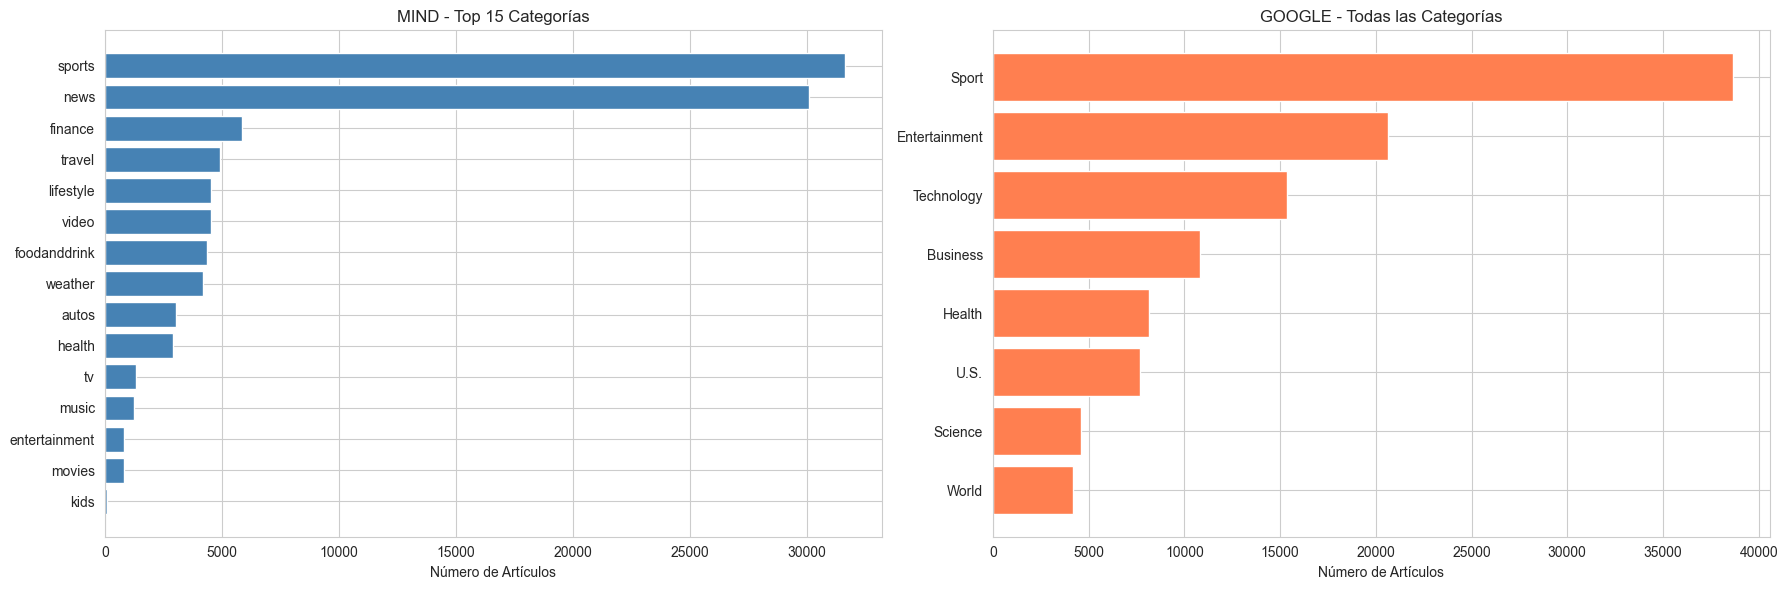

Gráfico guardado en: ../results/category_distribution.png


In [9]:
# Visualización de distribución de categorías - MIND
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# MIND
mind_top15 = mind_cat_counts.head(15)
axes[0].barh(range(len(mind_top15)), mind_top15.values, color='steelblue')
axes[0].set_yticks(range(len(mind_top15)))
axes[0].set_yticklabels(mind_top15.index)
axes[0].set_xlabel('Número de Artículos')
axes[0].set_title('MIND - Top 15 Categorías')
axes[0].invert_yaxis()

# GOOGLE
axes[1].barh(range(len(google_cat_counts)), google_cat_counts.values, color='coral')
axes[1].set_yticks(range(len(google_cat_counts)))
axes[1].set_yticklabels(google_cat_counts.index)
axes[1].set_xlabel('Número de Artículos')
axes[1].set_title('GOOGLE - Todas las Categorías')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../results/category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: ../results/category_distribution.png")

## 5. Análisis de Subcategorías

In [10]:
print("=== SUBCATEGORÍAS - MIND ===")
mind_subcat_counts = df_mind['subcategory'].value_counts()
print(f"Número de subcategorías únicas: {len(mind_subcat_counts)}")
print("\nTop 10 subcategorías:")
print(mind_subcat_counts.head(10))

print("\n=== SUBCATEGORÍAS - GOOGLE ===")
google_subcat_counts = df_google['subcategory'].value_counts()
print(f"Número de subcategorías únicas: {len(google_subcat_counts)}")
print("\nTop 10 subcategorías:")
print(google_subcat_counts.head(10))

=== SUBCATEGORÍAS - MIND ===
Número de subcategorías únicas: 284

Top 10 subcategorías:
subcategory
newsus               14290
football_nfl         11678
newspolitics          5077
weathertopstories     4196
newscrime             3620
baseball_mlb          3563
football_ncaa         3388
news                  3320
basketball_nba        3177
more_sports           2764
Name: count, dtype: int64

=== SUBCATEGORÍAS - GOOGLE ===
Número de subcategorías únicas: 42

Top 10 subcategorías:
subcategory
U.S.             7674
Sport            7637
Business         6350
Entertainment    6133
Technology       6118
Soccer           5332
World            4211
MLB              4079
NCAA Football    3889
NFL              3573
Name: count, dtype: int64


## 6. Análisis de Longitud de Texto

In [11]:
# Calcular longitudes de texto
df_mind['title_length'] = df_mind['title'].astype(str).apply(len)
df_mind['word_count'] = df_mind['title'].astype(str).apply(lambda x: len(x.split()))

df_google['title_length'] = df_google['title'].astype(str).apply(len)
df_google['word_count'] = df_google['title'].astype(str).apply(lambda x: len(x.split()))

print("=== ESTADÍSTICAS DE LONGITUD - MIND ===")
print(df_mind[['title_length', 'word_count']].describe())

print("\n=== ESTADÍSTICAS DE LONGITUD - GOOGLE ===")
print(df_google[['title_length', 'word_count']].describe())

=== ESTADÍSTICAS DE LONGITUD - MIND ===
        title_length     word_count
count  100304.000000  100304.000000
mean       67.148548      10.830126
std       286.666814      41.635648
min        11.000000       1.000000
25%        54.000000       8.000000
50%        64.000000      10.000000
75%        78.000000      13.000000
max     86060.000000   12495.000000

=== ESTADÍSTICAS DE LONGITUD - GOOGLE ===
        title_length     word_count
count  110105.000000  110105.000000
mean       72.052632      11.643622
std       171.362492      24.231332
min         3.000000       1.000000
25%        58.000000       9.000000
50%        69.000000      11.000000
75%        83.000000      13.000000
max     51211.000000    7244.000000


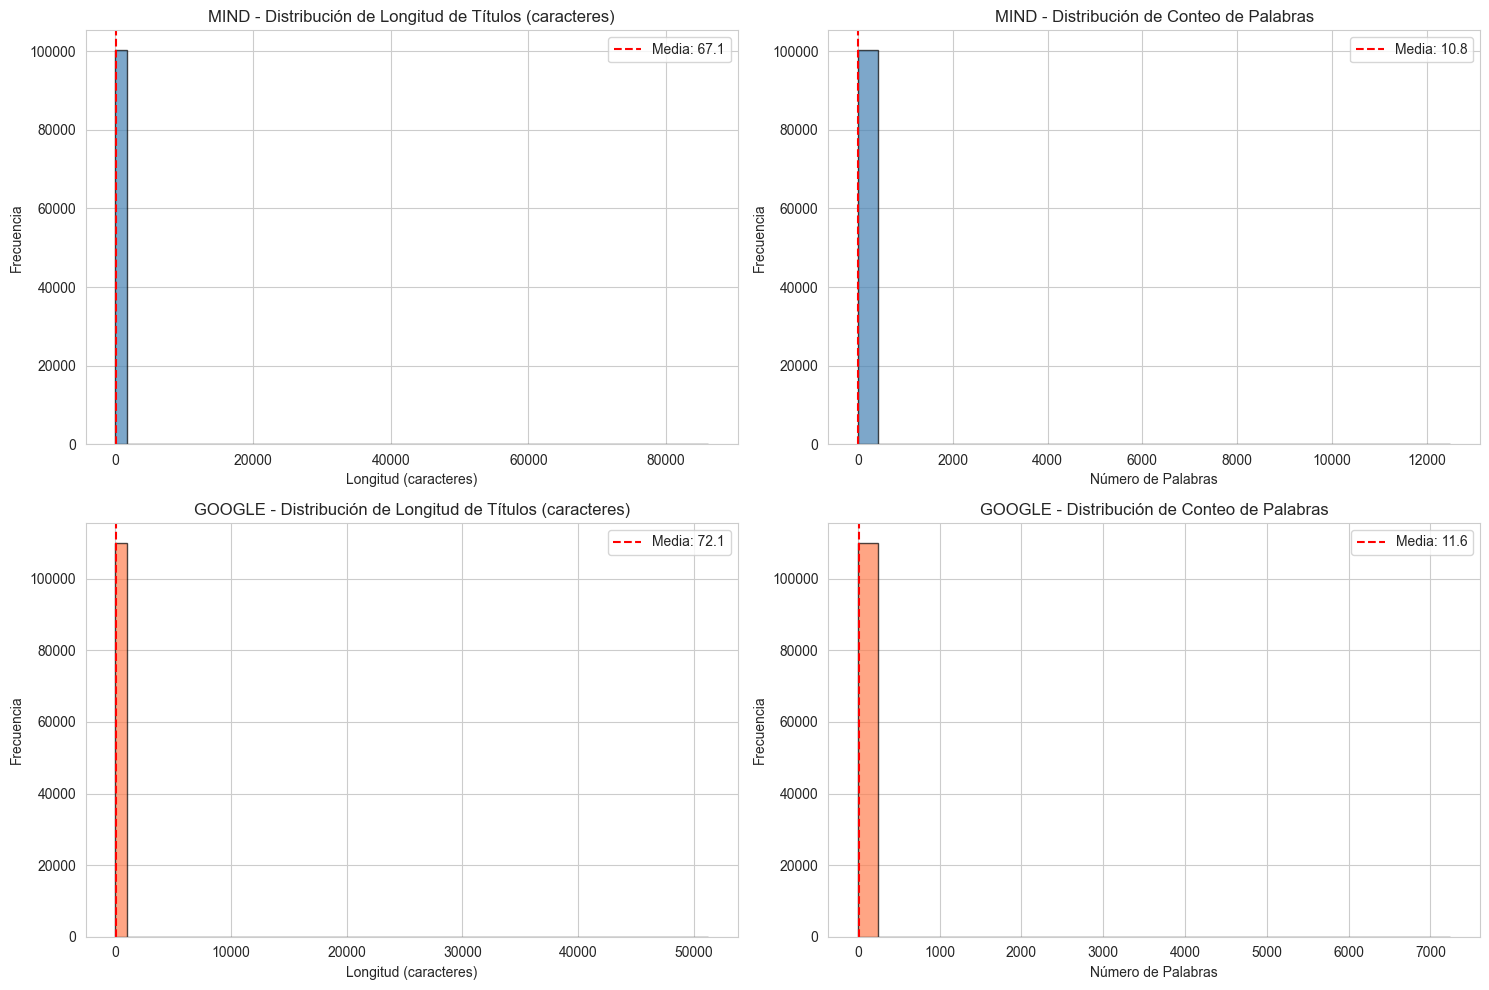

Gráfico guardado en: ../results/text_length_distribution.png


In [12]:
# Visualización de distribución de longitudes
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Longitud de caracteres - MIND
axes[0, 0].hist(df_mind['title_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Longitud (caracteres)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('MIND - Distribución de Longitud de Títulos (caracteres)')
axes[0, 0].axvline(df_mind['title_length'].mean(), color='red', linestyle='--', label=f'Media: {df_mind["title_length"].mean():.1f}')
axes[0, 0].legend()

# Conteo de palabras - MIND
axes[0, 1].hist(df_mind['word_count'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Número de Palabras')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('MIND - Distribución de Conteo de Palabras')
axes[0, 1].axvline(df_mind['word_count'].mean(), color='red', linestyle='--', label=f'Media: {df_mind["word_count"].mean():.1f}')
axes[0, 1].legend()

# Longitud de caracteres - GOOGLE
axes[1, 0].hist(df_google['title_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Longitud (caracteres)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('GOOGLE - Distribución de Longitud de Títulos (caracteres)')
axes[1, 0].axvline(df_google['title_length'].mean(), color='red', linestyle='--', label=f'Media: {df_google["title_length"].mean():.1f}')
axes[1, 0].legend()

# Conteo de palabras - GOOGLE
axes[1, 1].hist(df_google['word_count'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Número de Palabras')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('GOOGLE - Distribución de Conteo de Palabras')
axes[1, 1].axvline(df_google['word_count'].mean(), color='red', linestyle='--', label=f'Media: {df_google["word_count"].mean():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../results/text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: ../results/text_length_distribution.png")

## 7. Detección de Duplicados

In [13]:
# Duplicados en MIND
print("=== ANÁLISIS DE DUPLICADOS - MIND ===")
mind_dup_titles = df_mind['title'].duplicated().sum()
mind_dup_ids = df_mind['doc_id'].duplicated().sum()
print(f"Títulos duplicados: {mind_dup_titles:,} ({mind_dup_titles/len(df_mind)*100:.2f}%)")
print(f"IDs duplicados: {mind_dup_ids:,} ({mind_dup_ids/len(df_mind)*100:.2f}%)")

# Duplicados en GOOGLE
print("\n=== ANÁLISIS DE DUPLICADOS - GOOGLE ===")
google_dup_titles = df_google['title'].duplicated().sum()
google_dup_ids = df_google['doc_id'].duplicated().sum()
print(f"Títulos duplicados: {google_dup_titles:,} ({google_dup_titles/len(df_google)*100:.2f}%)")
print(f"IDs duplicados: {google_dup_ids:,} ({google_dup_ids/len(df_google)*100:.2f}%)")

=== ANÁLISIS DE DUPLICADOS - MIND ===
Títulos duplicados: 3,069 (3.06%)
IDs duplicados: 0 (0.00%)

=== ANÁLISIS DE DUPLICADOS - GOOGLE ===
Títulos duplicados: 0 (0.00%)
IDs duplicados: 0 (0.00%)


In [14]:
# Ejemplos de títulos duplicados
if mind_dup_titles > 0:
    print("=== EJEMPLOS DE TÍTULOS DUPLICADOS - MIND ===")
    dup_titles = df_mind[df_mind['title'].duplicated(keep=False)].sort_values('title')
    display(dup_titles.head(10))

if google_dup_titles > 0:
    print("\n=== EJEMPLOS DE TÍTULOS DUPLICADOS - GOOGLE ===")
    dup_titles = df_google[df_google['title'].duplicated(keep=False)].sort_values('title')
    display(dup_titles.head(10))

=== EJEMPLOS DE TÍTULOS DUPLICADOS - MIND ===


,doc_id,category,subcategory,title,source,title_length,word_count
22698,N11490,travel,travelnews,$2 million Florida Lottery ticket sold in Jack...,MIND,66,10
43083,N33885,travel,travelnews,$2 million Florida Lottery ticket sold in Jack...,MIND,66,10
53678,N88198,lifestyle,lifestylebuzz,$23 Million SuperLotto Plus Ticket Sold In San...,MIND,62,10
54622,N50689,news,newsus,$23 Million SuperLotto Plus Ticket Sold In San...,MIND,62,10
79614,N90278,sports,football_nfl,'A game-changer': Titans' expansion project wi...,MIND,88,12
77057,N89471,sports,football_nfl,'A game-changer': Titans' expansion project wi...,MIND,88,12
37336,N126676,news,newsoffbeat,'A very intelligent animal': Meet the pig who ...,MIND,103,16
30446,N15601,news,newsus,'A very intelligent animal': Meet the pig who ...,MIND,103,16
88535,N97946,news,newsus,'Baby Trump' balloon slashed at Alabama appear...,MIND,50,7
92422,N70872,news,newscrime,'Baby Trump' balloon slashed at Alabama appear...,MIND,50,7


## 8. Combinación de Datasets

In [15]:
# Combinar ambos datasets
df_combined = pd.concat([df_mind, df_google], ignore_index=True)
print(f"Dataset combinado: {len(df_combined):,} registros")
print(f"\nDistribución por fuente:")
print(df_combined['source'].value_counts())

# Verificar duplicados entre datasets
print(f"\n=== DUPLICADOS ENTRE DATASETS ===")
cross_duplicates = df_combined['title'].duplicated().sum()
print(f"Títulos duplicados en dataset combinado: {cross_duplicates:,}")

Dataset combinado: 210,409 registros

Distribución por fuente:
source
GOOGLE    110105
MIND      100304
Name: count, dtype: int64

=== DUPLICADOS ENTRE DATASETS ===
Títulos duplicados en dataset combinado: 3,070


## 9. Resumen del EDA

In [16]:
print("="*60)
print("RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS")
print("="*60)
print(f"\n1. TAMAÑO DE DATOS:")
print(f"   - MIND dataset: {len(df_mind):,} registros")
print(f"   - GOOGLE dataset: {len(df_google):,} registros")
print(f"   - Total combinado: {len(df_combined):,} registros")

print(f"\n2. CATEGORÍAS:")
print(f"   - MIND: {len(mind_cat_counts)} categorías únicas")
print(f"   - GOOGLE: {len(google_cat_counts)} categorías únicas")
print(f"   - MIND subcategorías: {len(mind_subcat_counts)}")
print(f"   - GOOGLE subcategorías: {len(google_subcat_counts)}")

print(f"\n3. LONGITUD DE TEXTO:")
print(f"   - MIND promedio: {df_mind['title_length'].mean():.1f} caracteres, {df_mind['word_count'].mean():.1f} palabras")
print(f"   - GOOGLE promedio: {df_google['title_length'].mean():.1f} caracteres, {df_google['word_count'].mean():.1f} palabras")

print(f"\n4. CALIDAD DE DATOS:")
print(f"   - Valores faltantes MIND: {df_mind.isnull().sum().sum()}")
print(f"   - Valores faltantes GOOGLE: {df_google.isnull().sum().sum()}")
print(f"   - Duplicados MIND: {mind_dup_titles:,}")
print(f"   - Duplicados GOOGLE: {google_dup_titles:,}")

print(f"\n5. PRÓXIMOS PASOS:")
print(f"   - Mapear categorías a clases binarias (Actualidad vs Interés General)")
print(f"   - Limpiar duplicados")
print(f"   - Normalizar categorías entre datasets")
print(f"   - Crear splits estratificados (70/20/10)")
print("="*60)

RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS

1. TAMAÑO DE DATOS:
   - MIND dataset: 100,304 registros
   - GOOGLE dataset: 110,105 registros
   - Total combinado: 210,409 registros

2. CATEGORÍAS:
   - MIND: 18 categorías únicas
   - GOOGLE: 8 categorías únicas
   - MIND subcategorías: 284
   - GOOGLE subcategorías: 42

3. LONGITUD DE TEXTO:
   - MIND promedio: 67.1 caracteres, 10.8 palabras
   - GOOGLE promedio: 72.1 caracteres, 11.6 palabras

4. CALIDAD DE DATOS:
   - Valores faltantes MIND: 0
   - Valores faltantes GOOGLE: 0
   - Duplicados MIND: 3,069
   - Duplicados GOOGLE: 0

5. PRÓXIMOS PASOS:
   - Mapear categorías a clases binarias (Actualidad vs Interés General)
   - Limpiar duplicados
   - Normalizar categorías entre datasets
   - Crear splits estratificados (70/20/10)


## 10. Guardar Dataset Combinado para el Siguiente Paso

In [17]:
# Guardar el dataset combinado para el siguiente notebook
output_path = '../data/processed/combined_raw.csv'
df_combined.to_csv(output_path, index=False)
print(f"Dataset combinado guardado en: {output_path}")
print(f"Tamaño: {len(df_combined):,} registros")

Dataset combinado guardado en: ../data/processed/combined_raw.csv
Tamaño: 210,409 registros
